# Train an LSTM for Time-Series Forecasting

## Methodology and Architecture

### Task Definition

For this project, AAPL (Apple Inc) closing stock prices from yahoo finance are used for predicting stock. This was done with an LSTM (Long Short-Term memory) neural network. Input includes a lookback window of 60 trading days with scaled closing prices; the outputs are predicted prices. The data is labeled with historical prices and dates, so this is a supervised deep learning regression task.

LSTM architecture is executed using Pytorch's nn.LSTM module which has forget, input, and output gates under the hood. This allows learning from sequential data with selective memory and avoids the vanishing gradient problem.

RMSE (Root Mean Square Error) is used as an evaluation metric. It measures the average difference between a model's predicted values and actual values.

### Data Preparation

This section includes  data preparation pipeline for AAPL dataset: data loading, exploratory data analysis, splitting, scaling, and sequence creation for LSTM input

In [2]:
!pip install yfinance

In [93]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

#### Data Loading and Feature Selection

Historical daily stock price data for AAPL was downloaded using the yfinance library, from January 1, 2015, to the present date. For this forecasting task, we will focus exclusively on the 'Close' price.

In [5]:
# Download AAPL data from January 1, 2015 to present time
ticker = 'AAPL'
start_date = datetime(year=2015, month=1, day=1)
end_date = datetime.now()

df_AAPL = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval='1d',
    auto_adjust=True,
    progress=True
)

[*********************100%***********************]  1 of 1 completed


In [6]:
df_AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2891 entries, 2015-01-02 to 2026-07-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2891 non-null   float64
 1   (High, AAPL)    2891 non-null   float64
 2   (Low, AAPL)     2891 non-null   float64
 3   (Open, AAPL)    2891 non-null   float64
 4   (Volume, AAPL)  2891 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.5 KB


In [7]:
df_AAPL.describe()
#volume is significantly different, but won't be used so scaling is not necessary for this variable
#Close, High, Low, Open have a range from ~20 to ~310

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2891.000000,2891.000000,2891.000000,2891.000000,2.891000e+03
mean,113.363469,114.504048,112.126629,113.266374,1.087773e+08
std,80.251258,81.056398,79.392719,80.178308,6.787961e+07
min,20.565872,20.868647,20.367818,20.488473,1.791060e+07
25%,37.292469,37.623274,36.966849,37.296342,6.117480e+07
50%,112.092567,113.644544,110.584258,112.273833,9.154160e+07
75%,173.331375,175.261016,171.490349,173.356738,1.347014e+08
max,315.200012,317.399994,309.649994,314.179993,6.488252e+08


In [8]:
df_AAPL.head()
#Need to get rid of ticker header and price description as it's misleading 
#Price for Volume doesn't make sense

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759087,24.816620,24.053201,24.170481,237458000


In [9]:
df_AAPL.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


In [10]:
df_AAPL.isna().sum()
#There is no missing data

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

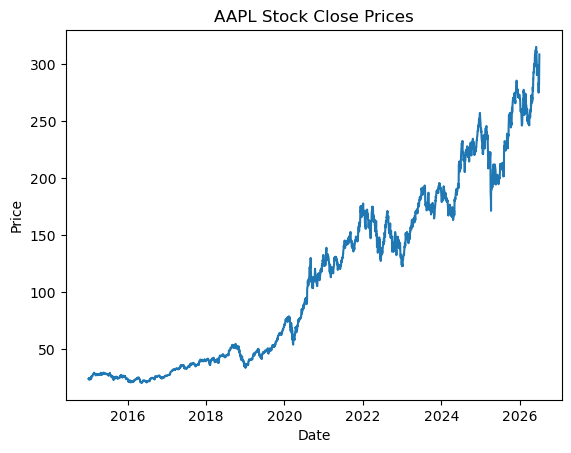

In [11]:
#Plotting and looking at Close prices since it is the main focus for training
plt.plot(df_AAPL.index, df_AAPL['Close'].values.astype('float32'), label='Close')
plt.title('AAPL Stock Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

#### Data EDA

In [12]:
df_AAPL = df_AAPL.dropna()
#Just in case since data is based on present time
#Weekends and holidays will produce NAN results

In [13]:
df_AAPL.columns = df_AAPL.columns.get_level_values(0)
#This entirely removes ticker header

In [14]:
df_AAPL.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759087,24.816620,24.053201,24.170481,237458000


In [15]:
df_AAPL.columns.name = None
#This removes column name, Price

In [16]:
df_AAPL.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511057,24.042131,23.325182,23.962469,257142000
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759087,24.816620,24.053201,24.170481,237458000


#### Train-Test Split

The data was split chronologically to simulate a real-world forecasting scenario.

Training Set: Data from 2015 up to the end of 2023. 
(9 years so 108 months)

Test Set: Data from the start of 2024 to the present
(30 months)

Total months = 108 + 30
Training percentage = 108/138 = 78%
Testing percentage = 30/138 = 22%

This splitting makes sense since a typical split is 70-80% for train set and 20-30% for test set.

In [17]:
#Train Set is 2015 to end of 2023
train_set = df_AAPL[df_AAPL.index < '2024-01-01']
#Test set is 2024 to present
test_set = df_AAPL[df_AAPL.index >= '2024-01-01']

#### Data Scaling

Per Dr.Pengfei Zhou's instructions,"Neural networks are sensitive to the scale of input data. To aid in model convergence, the 'Close' prices could be scaled to a range between 0 and 1 using MinMaxScaler from scikit-learn. <span style="color: red"> The scaler is fit only on the training data to prevent data leakage from the test set</span>".

In [18]:
scaler = MinMaxScaler(feature_range=(0,1))

In [19]:
#Formatting needs to be float32--Pytorch is not able to process float64 during training!

#Training set is scaled and fitted
train_set_fitted_scaled = scaler.fit_transform(train_set[['Close']].values.astype('float32'))

#Testing set is exclusively scaled with no fitting
test_set_scaled = scaler.transform(test_set[['Close']].values.astype('float32'))

In [20]:
#checking min and max values for scaled
print(train_set_fitted_scaled.max())
print(train_set_fitted_scaled.min())

1.0
0.0


In [21]:
#Checking min and max values for test set
print(test_set_scaled.max())
print(test_set_scaled.min())

1.6804863
0.81445396


#### Sequence Creation

LSTM are trained on sequences of data and needs overlapping windows of a specific time. A lookback window of 60 previous days is used as input (x) for closing price of the next day (y). By having this approach, it limits the model to a limited period length rather than long term and retains chronological sequence.  

Code for the following function create_dataset, class StockLSTM, and train_evaluate_model code were obtained from here:

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

In [22]:
def create_dataset(dataset,lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))
    #Numpy works better with a numpy array rather than a list of arrays

In [23]:
# Per instructions, a lookback window of 60 days should be used
lookback = 60

In [24]:
X_train, y_train = create_dataset(train_set_fitted_scaled, lookback=lookback)
X_test, y_test = create_dataset(test_set_scaled, lookback=lookback)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2204, 60, 1]) torch.Size([2204, 60, 1])
torch.Size([567, 60, 1]) torch.Size([567, 60, 1])


## Training and Optimization

I experimented with 7 different configuration: baseline model, different hidden sizes (100 and 200), 2 layers, longer lookback window (100), faster learning rate, and early stopping.

MSE loss was used as loss function during training. It is converted to RMSE for both training and testing sets and was plotted to understand performance. Ideal trends include decreasing and stable RMSE values as epoch increase and a small gap between training and testing curves.

A final model was built with favorable configurations that improved performance and efficiency: hidden size 100 and early stopping. The rest of the configurations were either too unstable because of overfitting, not capturing patterns well, or did not have significant improvement.

Classes and functions were created for model training, evaluation, and visualization.

Adam optimizer was chosen since it is well-balanced. Default learning rate of 0.001 was used.

Debugging includes :
    
    Using cpu().item() to convert tensor to python float. This prevents deprecated warnings.
    
    Data processing the multiindex column names from yfinance and converting to float32 for Pytorch compatability

    Properly displaying years on prediction plot instead of days

Resource for LSTM optimization: 

https://codesignal.com/learn/courses/time-series-forecasting-with-lstms/lessons/optimizing-lstm-performance-for-time-series-forecasting

Resource for early stopping: 

https://www.geeksforgeeks.org/deep-learning/how-to-handle-overfitting-in-pytorch-models-using-early-stopping/

In [25]:
#Dataset is small of only 2891 entries so only training set has loader
loader = data.DataLoader(
    dataset = data.TensorDataset(X_train, y_train), 
    shuffle = True, 
    batch_size = 8
)

In [26]:
loss_fn = nn.MSELoss()

In [27]:
#Defining variables for plotting predictions
full_timeseries = np.concatenate([train_set_fitted_scaled, test_set_scaled])

train_size = len(train_set_fitted_scaled)

#Extracting date for plotting later
date = df_AAPL.index

In [28]:
#function to reset random seeds for consistency
def reset_seeds():
    torch.manual_seed(33)
    random.seed(33)
    np.random.seed(33)

In [29]:
#Class for creating models
class StockLSTM(nn.Module):
    def __init__(self, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, 
                            hidden_size=hidden_size,
                            num_layers=num_layers, 
                            batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

In [30]:
#Class for EarlyStopping
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience #number of bad checks before stopping
        self.delta = delta #minimum improvment threshold
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None #saved weights

    def __call__(self, val_loss, model):
        score = -val_loss

        #When there is no previous score, we save it
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
            
        # If score is not better than score +delta, then bad counter increases
        elif score < self.best_score + self.delta:
            self.counter += 1
            #Early stop when patience is reached
            if self.counter >= self.patience:
                self.early_stop = True
                
        #When score is better, update the best score
        else:
            self.best_score = score
            self.best_model_state = model.state_dict() #save new weights
            self.counter = 0

    #Selects the best model from earlier epoch
    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [58]:
#Function to train the model and evaluate (with RMSE)
def train_evaluate_model(model, epoch, optimizer, 
                         loss_fn=loss_fn,
                         loader=loader,
                         early_stopper=None):
    
    train_rmse_list = []
    test_rmse_list = []
    
    for i in range(epoch):
        model.train()
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad() #clears gradient before backward pass
            loss.backward()
            optimizer.step()

        if i % 10 == 0:
            model.eval()
            with torch.no_grad():
                y_pred = model(X_train)
                #.cpu().item() was added to convert tensor to python float to avoid deprecated warning
                train_rmse = np.sqrt(loss_fn(y_pred, y_train).cpu().item())
                y_pred = model(X_test)
                test_rmse = np.sqrt(loss_fn(y_pred, y_test).cpu().item())
            
            train_rmse_list.append(train_rmse)
            test_rmse_list.append(test_rmse)
            print(f"Epoch {i}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

            #Early Stopping Section
            if early_stopper is not None:
                early_stopper(test_rmse,model)
                if early_stopper.early_stop:
                    print(f'Early stop at Epoch {i}')
                    break
    
    return train_rmse_list, test_rmse_list

In [32]:
# Plot for training vs testing losses (RMSE)
def plot_loss(train_rmse, test_rmse):
    plt.plot(train_rmse, label='Train RMSE')
    plt.plot(test_rmse, label='Test RMSE')
    plt.xlabel('Epochs (every 10)')
    plt.ylabel('RMSE (scaled)')
    plt.title('Training and Test Loss Curve')
    plt.legend()
    plt.show()

In [66]:
# Function for plotting predictions from training and testing sets in comparison to actual
def plot_predictions(model, full_timeseries):
    with torch.no_grad():
        #shift train predictions for plotting
        train_plot = np.ones_like(full_timeseries) * np.nan
        y_pred_train = model(X_train).cpu().numpy()
        pred_length = len(y_pred_train)
        train_plot[lookback:lookback+pred_length] = y_pred_train[:, -1, :]
        
        # shift test predictions for plotting
        test_plot = np.ones_like(full_timeseries) * np.nan
        y_pred_test = model(X_test).cpu().numpy()
        pred_length_test = len(y_pred_test)
        test_plot[train_size+lookback:train_size+lookback+pred_length_test] = y_pred_test[:, -1, :]
    
    plt.plot(date, full_timeseries, label='Actual', c='b')
    plt.plot(date, train_plot, label='Train Predictions', c='r')
    plt.plot(date, test_plot, label='Test Predictions', c='g')
    plt.legend()
    plt.title('AAPL Stock Price Prediction')
    plt.xlabel('Year')
    plt.ylabel('Price USD (scaled)')
    plt.show()

### Experiment 1: Baseline

In an example provided, they had 2000 epochs, but I think it was more reasonable to try with a smaller number. Since my function displayed every 10 epochs, I chose 101 to display 100 cleanly

In [34]:
reset_seeds()
model_1 = StockLSTM()
optimizer_1 = optim.Adam(model_1.parameters()) #optimizer default learning rate is 0.001

In [35]:
train_rmse_1, test_rmse_1 = train_evaluate_model(
    model_1, epoch=101, optimizer=optimizer_1)

Epoch 0: train RMSE 0.0589, test RMSE 0.1717
Epoch 10: train RMSE 0.0105, test RMSE 0.0228
Epoch 20: train RMSE 0.0106, test RMSE 0.0254
Epoch 30: train RMSE 0.0104, test RMSE 0.0252
Epoch 40: train RMSE 0.0103, test RMSE 0.0262
Epoch 50: train RMSE 0.0102, test RMSE 0.0248
Epoch 60: train RMSE 0.0105, test RMSE 0.0267
Epoch 70: train RMSE 0.0102, test RMSE 0.0241
Epoch 80: train RMSE 0.0102, test RMSE 0.0248
Epoch 90: train RMSE 0.0104, test RMSE 0.0263
Epoch 100: train RMSE 0.0103, test RMSE 0.0253


Base model is working well since the RMSE values for both train and test RMSE are low

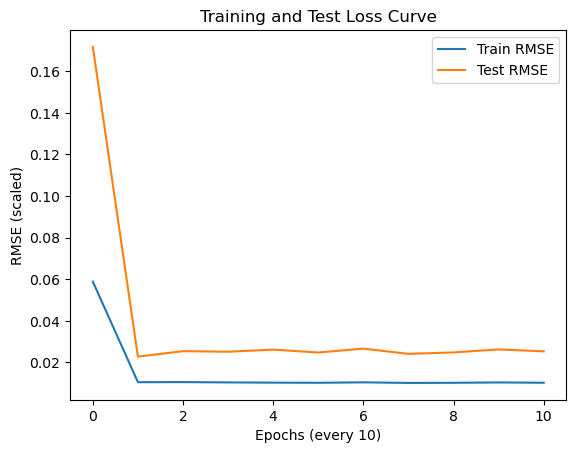

In [36]:
plot_loss(train_rmse_1, test_rmse_1)

### Experiment 2: Different Hidden Sizes (100)

The capacity for LSTM to learn patterns. I experimented with 100 and 200. 

In [37]:
reset_seeds()
model_2 = StockLSTM(hidden_size=100)
optimizer_2 = optim.Adam(model_2.parameters())

In [38]:
train_rmse_2, test_rmse_2 = train_evaluate_model(
    model_2, epoch=101, optimizer=optimizer_2)

Epoch 0: train RMSE 0.0619, test RMSE 0.1701
Epoch 10: train RMSE 0.0109, test RMSE 0.0255
Epoch 20: train RMSE 0.0102, test RMSE 0.0233
Epoch 30: train RMSE 0.0102, test RMSE 0.0240
Epoch 40: train RMSE 0.0108, test RMSE 0.0295
Epoch 50: train RMSE 0.0103, test RMSE 0.0256
Epoch 60: train RMSE 0.0104, test RMSE 0.0259
Epoch 70: train RMSE 0.0102, test RMSE 0.0259
Epoch 80: train RMSE 0.0102, test RMSE 0.0263
Epoch 90: train RMSE 0.0102, test RMSE 0.0254
Epoch 100: train RMSE 0.0102, test RMSE 0.0239


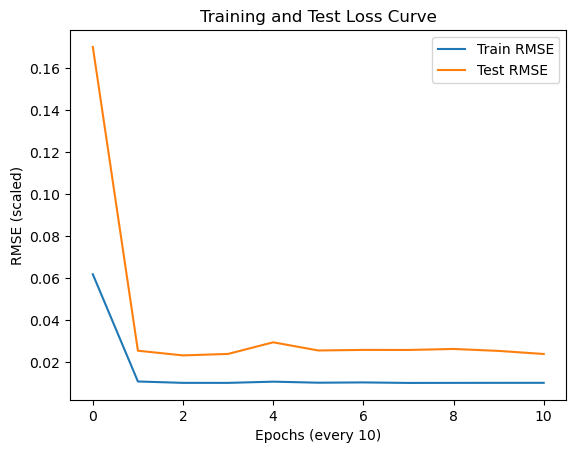

In [39]:
plot_loss(train_rmse_2, test_rmse_2)

Numerically hidden size 100 seems to be slightly better than baseline. The overall curves are stable

### Experiment 3: Different Hidden Size (200)

In [40]:
reset_seeds()
model_3 = StockLSTM(hidden_size=200)
optimizer_3 = optim.Adam(model_3.parameters())

In [41]:
train_rmse_3, test_rmse_3 = train_evaluate_model(
    model_3, epoch=101, optimizer=optimizer_3)

Epoch 0: train RMSE 0.0542, test RMSE 0.1451
Epoch 10: train RMSE 0.0102, test RMSE 0.0225
Epoch 20: train RMSE 0.0104, test RMSE 0.0217
Epoch 30: train RMSE 0.0102, test RMSE 0.0224
Epoch 40: train RMSE 0.0102, test RMSE 0.0252
Epoch 50: train RMSE 0.0102, test RMSE 0.0264
Epoch 60: train RMSE 0.0102, test RMSE 0.0245
Epoch 70: train RMSE 0.0104, test RMSE 0.0225
Epoch 80: train RMSE 0.0103, test RMSE 0.0251
Epoch 90: train RMSE 0.0104, test RMSE 0.0231
Epoch 100: train RMSE 0.0103, test RMSE 0.0262


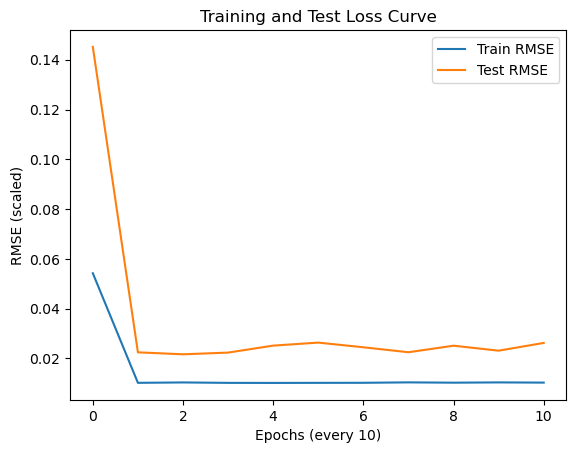

In [42]:
plot_loss(train_rmse_3, test_rmse_3)

Testing curve is not as stable anymore and has a upward trend towards the end

### Experiment 4: Layer (2)

In [43]:
reset_seeds()
model_4 = StockLSTM(num_layers=2)
optimizer_4 = optim.Adam(model_4.parameters())

In [44]:
train_rmse_4, test_rmse_4 = train_evaluate_model(
    model_4, epoch=101, optimizer=optimizer_4)

Epoch 0: train RMSE 0.0607, test RMSE 0.1798
Epoch 10: train RMSE 0.0115, test RMSE 0.0385
Epoch 20: train RMSE 0.0128, test RMSE 0.0238
Epoch 30: train RMSE 0.0104, test RMSE 0.0272
Epoch 40: train RMSE 0.0103, test RMSE 0.0275
Epoch 50: train RMSE 0.0107, test RMSE 0.0259
Epoch 60: train RMSE 0.0103, test RMSE 0.0263
Epoch 70: train RMSE 0.0108, test RMSE 0.0307
Epoch 80: train RMSE 0.0102, test RMSE 0.0267
Epoch 90: train RMSE 0.0101, test RMSE 0.0255
Epoch 100: train RMSE 0.0107, test RMSE 0.0326


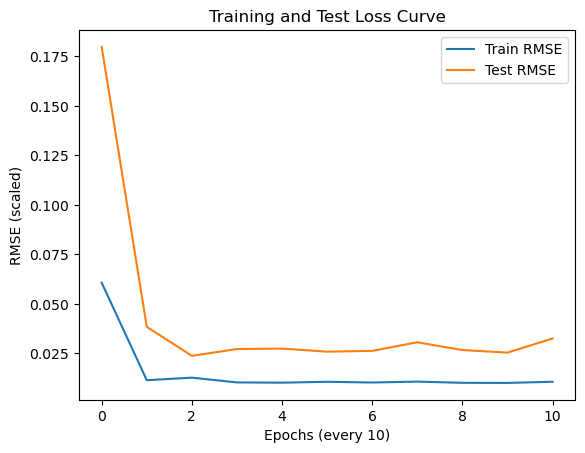

In [45]:
plot_loss(train_rmse_4, test_rmse_4)

Having an extra layer increased RMSE and instability

### Experiment 5: Longer Lookback

Even though 60 (days) is suggested and I understand the reasoning behind it. This is approximately 3 months and probably used for quarterly reports. However, I want to try a longer lookback and see if it makes a difference.

In [46]:
#Using the scaled data from before
X_train_2, y_train_2 = create_dataset(train_set_fitted_scaled, lookback=100)
X_test_2, y_test_2 = create_dataset(test_set_scaled, lookback=100)

In [47]:
loader2 = data.DataLoader(
    dataset = data.TensorDataset(X_train_2, y_train_2), 
    shuffle = True, 
    batch_size = 8
)

In [48]:
reset_seeds()
model_5 = StockLSTM()
optimizer_5 = optim.Adam(model_5.parameters())

In [49]:
train_rmse_5, test_rmse_5 = train_evaluate_model(
    model_5, epoch=101, optimizer=optimizer_5)

Epoch 0: train RMSE 0.0589, test RMSE 0.1717
Epoch 10: train RMSE 0.0105, test RMSE 0.0228
Epoch 20: train RMSE 0.0106, test RMSE 0.0254
Epoch 30: train RMSE 0.0104, test RMSE 0.0252
Epoch 40: train RMSE 0.0103, test RMSE 0.0262
Epoch 50: train RMSE 0.0102, test RMSE 0.0248
Epoch 60: train RMSE 0.0105, test RMSE 0.0267
Epoch 70: train RMSE 0.0102, test RMSE 0.0241
Epoch 80: train RMSE 0.0102, test RMSE 0.0248
Epoch 90: train RMSE 0.0104, test RMSE 0.0263
Epoch 100: train RMSE 0.0103, test RMSE 0.0253


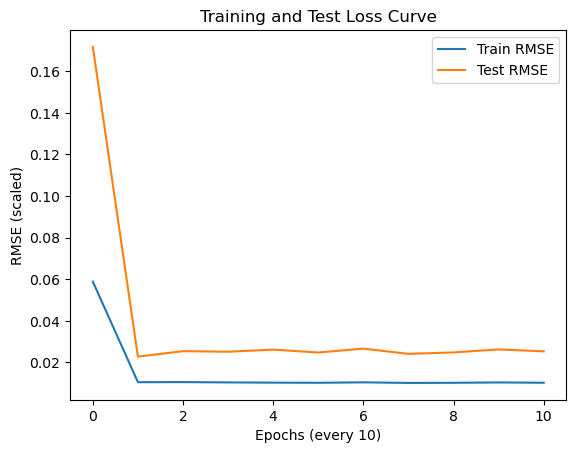

In [50]:
plot_loss(train_rmse_5, test_rmse_5)

No significant changes to note

### Experiment 6: Faster Learning Rate

Default learning rate is 0.001 and faster learning rate of 0.01 was used instead.

In [51]:
reset_seeds()
model_6 = StockLSTM()
optimizer_6 = optim.Adam(model_6.parameters(), lr=0.01)

In [52]:
train_rmse_6, test_rmse_6 = train_evaluate_model(
    model_6, epoch=101, optimizer=optimizer_6)

Epoch 0: train RMSE 0.0185, test RMSE 0.0515
Epoch 10: train RMSE 0.0109, test RMSE 0.0346
Epoch 20: train RMSE 0.0128, test RMSE 0.0426
Epoch 30: train RMSE 0.0104, test RMSE 0.0355
Epoch 40: train RMSE 0.0105, test RMSE 0.0233
Epoch 50: train RMSE 0.0114, test RMSE 0.0322
Epoch 60: train RMSE 0.0106, test RMSE 0.0289
Epoch 70: train RMSE 0.0119, test RMSE 0.0377
Epoch 80: train RMSE 0.0102, test RMSE 0.0262
Epoch 90: train RMSE 0.0102, test RMSE 0.0264
Epoch 100: train RMSE 0.0103, test RMSE 0.0246


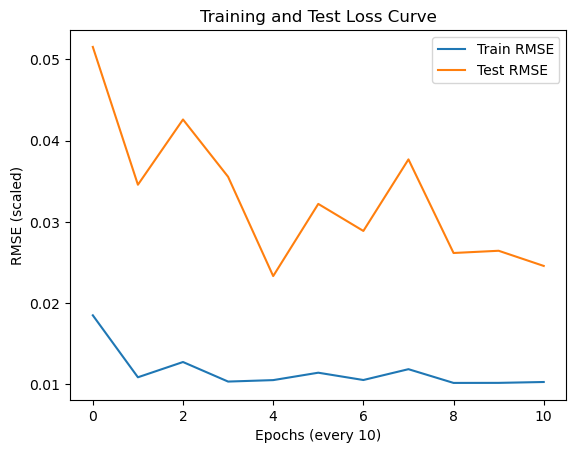

In [53]:
plot_loss(train_rmse_6, test_rmse_6)

Extreme, jagged lines from learning rate being too fast and the model is not stable

### Experiment 7: Early Stopping

For efficiency, early stopping can be implemented as it's a common mechanism for LSTM. It prevents overfitting, reduces processing time, and helps with generalization. 

From the example I found, they used patience of 5 and delta 0.001. I think these values are reasonable for this experiment. Looking at previous experiments, the improvements in training and test RMSE are around this level. 

In [56]:
reset_seeds()
model_7 = StockLSTM()
optimizer_7 = optim.Adam(model_7.parameters())
early_stopper = EarlyStopping(patience=5, delta=0.001)

In [59]:
train_rmse_7, test_rmse_7 = train_evaluate_model(
    model_7, epoch=101, optimizer=optimizer_7, early_stopper=early_stopper)

Epoch 0: train RMSE 0.0447, test RMSE 0.1291
Epoch 10: train RMSE 0.0106, test RMSE 0.0221
Epoch 20: train RMSE 0.0102, test RMSE 0.0226
Epoch 30: train RMSE 0.0102, test RMSE 0.0236
Epoch 40: train RMSE 0.0104, test RMSE 0.0270
Epoch 50: train RMSE 0.0103, test RMSE 0.0233
Epoch 60: train RMSE 0.0104, test RMSE 0.0241
Early stop at Epoch 60


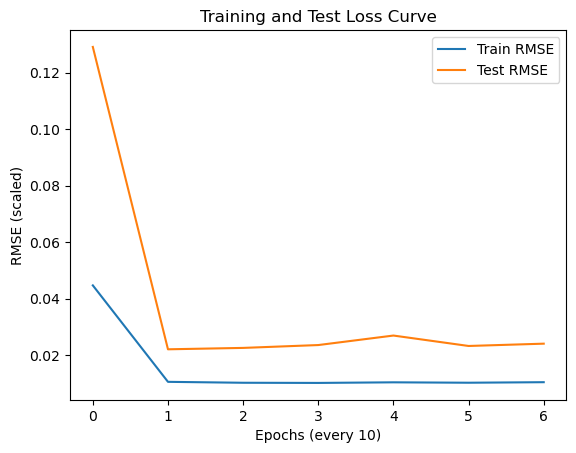

In [60]:
plot_loss(train_rmse_7, test_rmse_7)

With less epochs, the model is more efficient and better at generalizing

### Final Model

Hidden size 100 has a small improvement compared to baseline and early stopping helps with performance by reducing training time. The final models is a combination of both for performance and efficiency.

In [61]:
reset_seeds()
model_final = StockLSTM()
optimizer_final = optim.Adam(model_final.parameters())
early_stopper = EarlyStopping(patience=5, delta=0.001)

In [62]:
train_rmse_final, test_rmse_final = train_evaluate_model(
    model_final, epoch=101, optimizer=optimizer_final, early_stopper=early_stopper)

Epoch 0: train RMSE 0.0589, test RMSE 0.1717
Epoch 10: train RMSE 0.0105, test RMSE 0.0228
Epoch 20: train RMSE 0.0106, test RMSE 0.0254
Epoch 30: train RMSE 0.0104, test RMSE 0.0252
Epoch 40: train RMSE 0.0103, test RMSE 0.0262
Epoch 50: train RMSE 0.0102, test RMSE 0.0248
Epoch 60: train RMSE 0.0105, test RMSE 0.0267
Early stop at Epoch 60


## Final Model Evaluation

For the final model evaluation, RMSE and several visualizations were plotted: prediction plot comparing actual vs predicted, a scatter plot with 95% confidence interval, a residual plot, and a residual historgram. Results from all evaluations indicate high prediction accuracy with low systemic bias. This is confirmed with the random, normal distribution and close clustering with the fitted line.

In [71]:
#Extracting predicted and actual values from the Final Model
model_final.eval()
with torch.no_grad():
    y_pred_test = model_final(X_test).cpu().numpy()
    y_actual_test = y_test.cpu().numpy()
    
predicted = y_pred_test[:, -1, :]
actual = y_actual_test[:, -1, :]

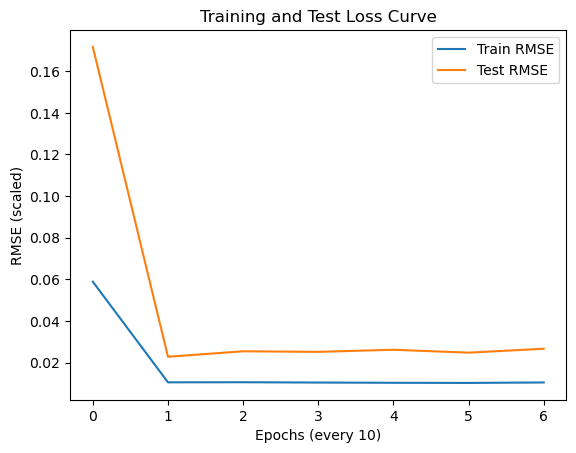

In [64]:
plot_loss(train_rmse_final, test_rmse_final)

Training and test loss curves are ideal. They are decreasing, have low RMSE, and a small gap between the two curves.

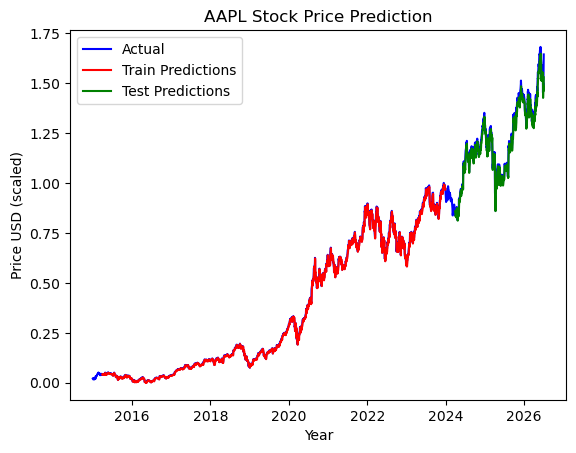

In [67]:
plot_predictions(model_final, full_timeseries)

The actual stock prices are mostly covered by train and test predictions. The model seems really good for making predictions. Notice the exposed gap (with blue) in between red (train predictions) amd green (test predictions). This is to be expected, because a 60 day lookback window is required before predictionn

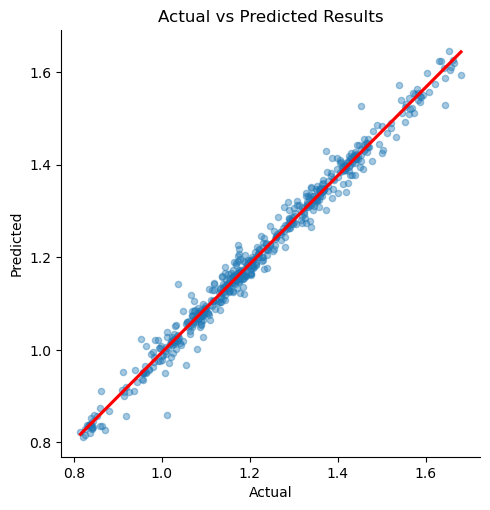

In [152]:
#Creating dataframe to use seaborn plot
#Confidence interval is automatically plotted
df_results = pd.DataFrame({
    'Actual': actual.flatten(),
    'Predicted': predicted.flatten()
})

sns.lmplot(data=df_results,
           x='Actual',
           y='Predicted',
           line_kws={'color': 'red'},
           scatter_kws={"s": 20, 'alpha': 0.4},
           ci=95)

plt.title('Actual vs Predicted Results')
plt.show()

The regression line is well fitted. The close clustering shows actual and predicted values have small variance. Confidence interval of 95% is plotted but is not visually seen. This suggests that the model is predicting closely with the actual values with high certainty.

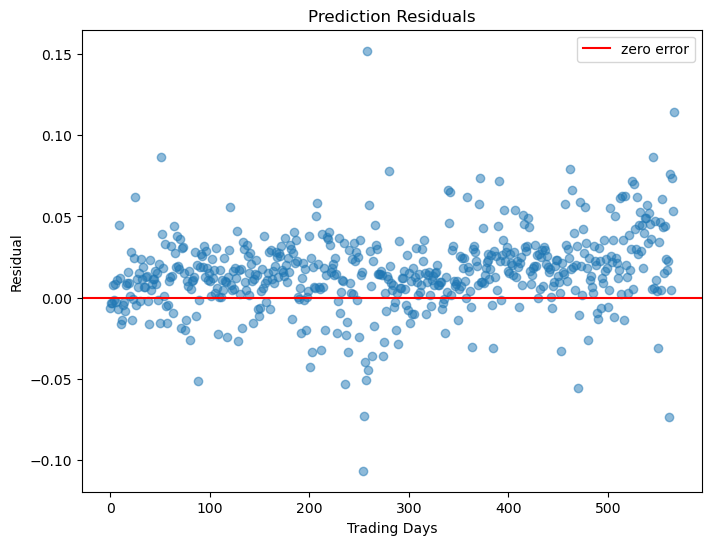

In [113]:
residuals = actual - predicted

plt.figure(figsize=(8, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(y=0, color='red', label='zero error')
plt.xlabel('Trading Days')
plt.ylabel('Residual')
plt.title('Prediction Residuals')
plt.legend()sns.distplot(residual)
plt.show()

Most of the residuals are near 0 meaning that the model predicts the closing prices accurately. The points also seem randomly scattered showing signs of homoscedasticity. 

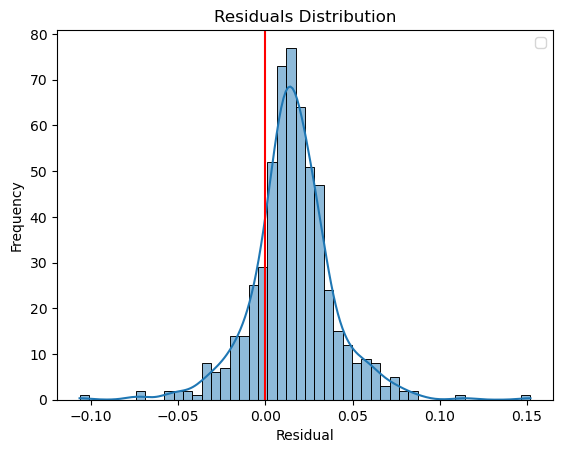

In [151]:
sns.histplot(residuals, kde=True)

plt.legend([]) #gets rid of legend that's automatically generated 
plt.axvline(x=0, color='red')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')

plt.show()

The residuals have a normal distribution around 0, showing that the errors are random. The residual's peak is slightly higher (~0.02) probably due to the unpredictable market trends in stock prices.

In [153]:
torch.save(model_final.state_dict(), 'model_proj2.pth')

## Reflection and Analysis

### Technical challenges, Failures, Debugging:

Some technical challenges and debugging that I dealt with were the data itself, incompatiblity issues that was crashing my kernel, tensor to numpy conversion, float32 compatability, and functions and training loop.

yfinance returned MultiIndex column structure which I was not familiar with. I had to search and experiment with ways to remove AAPL ticker and removing 'Price' from axis label. I used get_level_values(0) to flatten column names.

My kernel kept dying when I was trying to plot with matplotlib. There was a compatiblity issue. I had to recreate a new conda environment and carefully ordered my package installation and versions.

Deprecated warnings from incompatible data types kept arising when dealing with Pytorch tensors. Explicit conversion was needed with .cpu().item. In addition, I learned Pytorch needs float32 (yfinance returned float64) formatting for numbers and this prevented the model from training.

Putting together reusable functions and components for training and evaluation was difficult as well. Hyperparameters like hidden size, learning rate, lookback, and number of layers needed to be considered carefully since they're located in different parts.

I was unable to figure out how to plot stock prediction with correctly scaled prices. I tried inverse transforming, but the plot was not displaying prices correctly. I chose to leave it scaled since the main purpose was understanding how close the predictions were to actual

### Key successes, breakthroughs, and takeaways

Baseline model performed very well and did not require that many changes. After experimenting with other hyperparameters, there wasn't much of a point to improve the model and lower RMSE.

I shifted my perspective to create something more efficient hence the implementation of early stopping. My final model included early stopping and hidden size 100 which reduces training time and slightly decreased training and testing RMSE.

### What Failed

Faster learning rate was the worst of the experiments with extreme jagged RMSE lines and instability. This was to be expected since it can skip over the lowest point of a loss curve and not converge.

2 layers for LSTM was surprisingly a little worse than baseline. Somehow adding complexity made the model perform worse with testing RMSE increasing in later epochs. Maybe there was overfitting. This shows that simplicity is better than unecessary complexity.